# Player trajectory forecasting: reproduced models and deployment evidence

**Snapshot: September 21, 2026 Pacific / September 22 UTC.** Alvaro Mendizabal.

The task is to forecast player x/y positions after a pass using observed tracking, supplied landing location, player roles, and horizon. This review shows the latest completed experiments, retained negative evidence, and the deployment boundary. It uses aggregate receipts only; no AWS credentials, player identities, raw tracking, labels, or fitted weights are needed.

## Representation and architecture

The recreated base uses 20 observed frames, 10 dynamic channels, 12 static channels, grouped temporal convolutions, cross-player attention, and a trajectory decoder with positional and auxiliary Gaussian objectives. Exponential moving-average weights are retained for inference. Source-faithful normalization constants are fixed from the upstream implementation, not newly fitted within these folds. This is a component reproduction, not reproduction of the complete winning ensemble.

Research reference: [ohkawa3 / chack3 training notebook](https://www.kaggle.com/code/chack3/nfl2026-1st-place-train), captured source hash `6be46a4a8beccf14a65bbe3a18fd233cd00fc7d2281b1f396c08e5ba7e6f0fc2`; archived upstream notice identifies Apache-2.0.

## Validation and provenance

Metric: the square root of the mean squared error over both coordinates. Five seed-0 game-grouped folds cover 561,607 retained rows. Each OOF row comes from its excluded-fold model. Checkpoints were selected on these folds; the score is model-selection evidence, not an untouched final assessment. The source-faithful training population excluded five plays. Equal-weight averaging of the five models is reserved for new inputs and is not evaluated as OOF on their training rows.

In [1]:
import json, math, io, base64
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
E=json.loads(Path('research/evidence/model_reproduction.json').read_text())
def show(fig, static, name):
    fig.update_layout(width=900,height=480,margin=dict(l=80,r=40,t=70,b=70),font=dict(size=14))
    static.set_size_inches(9,4.8);static.tight_layout()
    buf=io.BytesIO();static.savefig(buf,format='png',dpi=120)
    Path('research/figures').mkdir(exist_ok=True)
    Path('research/figures/'+name+'.png').write_bytes(buf.getvalue())
    display({'application/vnd.plotly.v1+json':json.loads(fig.to_json()),'image/png':base64.b64encode(buf.getvalue()).decode()},raw=True)
    plt.close(static)
n=sum(f['rows'] for f in E['base_folds'])
r=math.sqrt(sum(f['rows']*f['rmse']**2 for f in E['base_folds'])/n)
assert n==561607 and abs(r-E['base_oof_rmse'])<1e-12
print(f'Preserved base: {r:.9f} coordinate RMSE, {n:,} out-of-fold rows.')
print('Selected checkpoints; not an untouched test. No new Kaggle score.')


Preserved base: 0.468143852 coordinate RMSE, 561,607 out-of-fold rows.
Selected checkpoints; not an untouched test. No new Kaggle score.


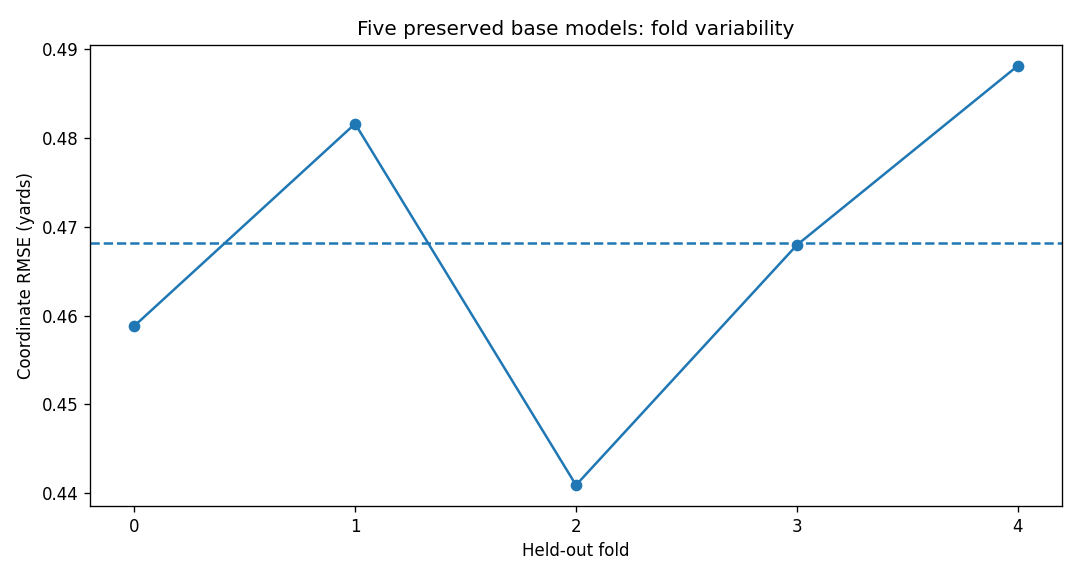

In [2]:
f=E['base_folds']; x=[str(v['fold']) for v in f]; y=[v['rmse'] for v in f]
fig=go.Figure(go.Scatter(x=x,y=y,mode='markers+lines',name='Excluded-fold base',text=[str(v['rows'])+' rows' for v in f]))
fig.update_layout(title='Five preserved base models: fold variability',xaxis_title='Held-out fold',yaxis_title='Coordinate RMSE (yards; lower is better)')
fig.add_hline(y=E['base_oof_rmse'],line_dash='dash',annotation_text='Pooled OOF')
static,ax=plt.subplots();ax.plot(x,y,marker='o');ax.axhline(E['base_oof_rmse'],linestyle='--');ax.set(xlabel='Held-out fold',ylabel='Coordinate RMSE (yards)',title='Five preserved base models: fold variability')
show(fig,static,'winner_folds')


Fold variation is substantial. The pooled score weights squared errors by row counts before taking the square root; it is not an unweighted average of fold RMSEs. The historical 0.70090 post-deadline private submission belongs to an earlier model and a different evaluation population.

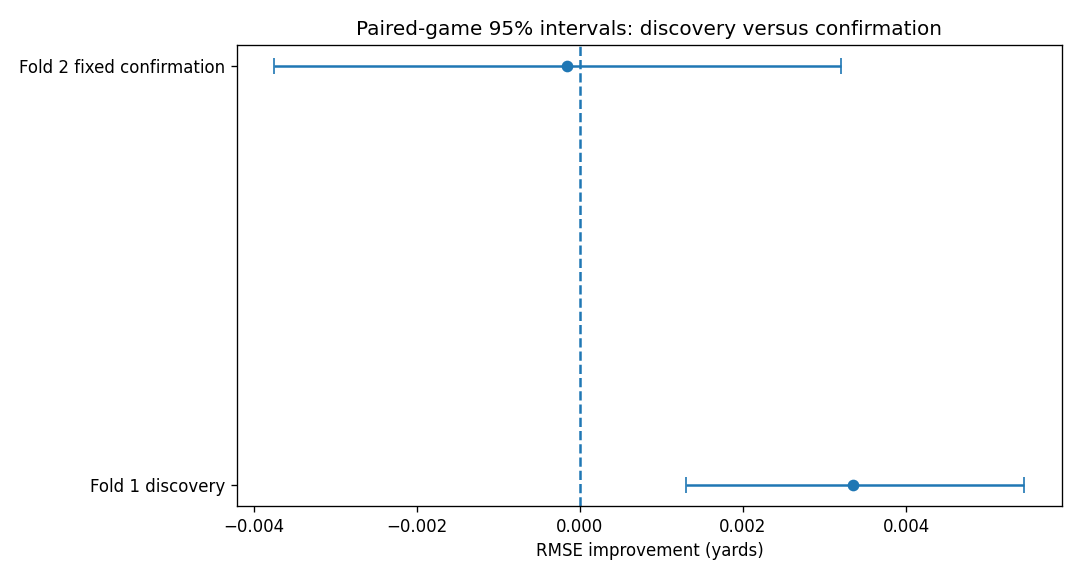

In [3]:
trials=E['rot']; labels=[t['stage'] for t in trials]; gains=[t['gain'] for t in trials]
low=[t['gain']-t['interval95'][0] for t in trials];high=[t['interval95'][1]-t['gain'] for t in trials]
fig=go.Figure(go.Scatter(x=gains,y=labels,mode='markers',error_x=dict(type='data',array=high,arrayminus=low,symmetric=False)))
fig.update_layout(title='ROT fixed 50/50 blend: discovery did not replicate',xaxis_title='Base RMSE minus blend RMSE (positive is better)',yaxis_title='Experiment')
fig.add_vline(x=0,line_dash='dash')
static,ax=plt.subplots();ax.errorbar(gains,labels,xerr=[low,high],fmt='o',capsize=5);ax.axvline(0,linestyle='--');ax.set(xlabel='RMSE improvement (yards)',title='Paired-game 95% intervals: discovery versus confirmation')
show(fig,static,'winner_confirmation')


The discovery chose epoch 22 on Fold 1. Confirmation fixed that epoch and the 50/50 weight in advance on Fold 2, using a fresh fit excluding its games. The gate required at least 0.001 RMSE improvement and a paired-game interval lower bound above zero. Fold 2 failed both conditions. These are saved experiment intervals, not a bootstrap re-run by this notebook. Cross-fold training overlap and prior model selection limit independence. ROT remains unpromoted; NORB remains NO_PROMOTION.

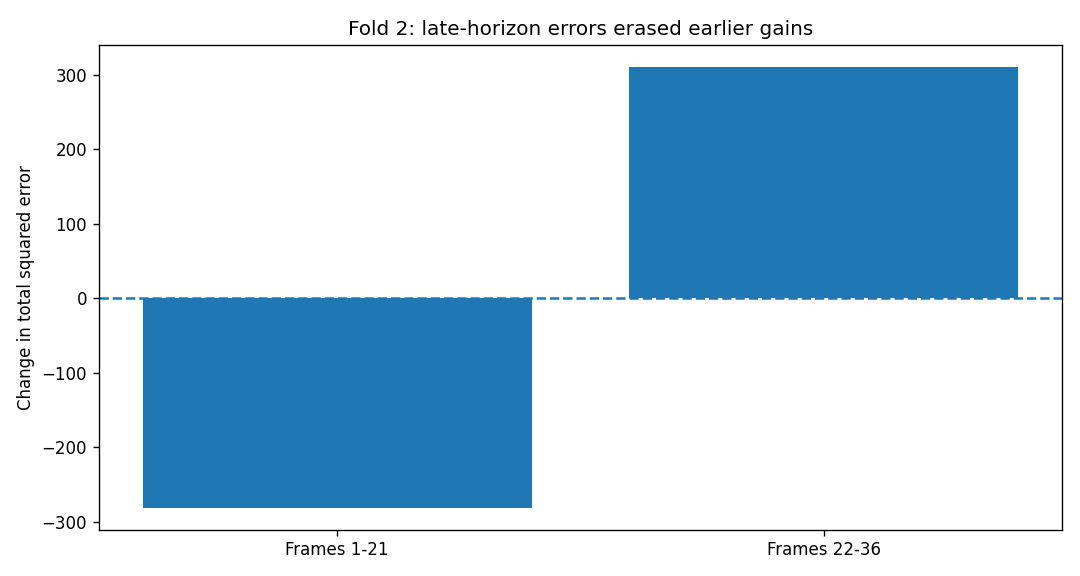

In [4]:
s=E['horizon_segments'];labels=[v['segment'] for v in s];delta=[v['delta_sse'] for v in s]
fig=go.Figure(go.Bar(x=labels,y=delta,text=[str(v['rows'])+' rows' for v in s]))
fig.update_layout(title='Fold 2: late-horizon errors erased earlier gains',xaxis_title='Forecast segment',yaxis_title='Blend minus base total squared error (yards squared)')
static,ax=plt.subplots();ax.bar(labels,delta);ax.axhline(0,linestyle='--');ax.set(ylabel='Change in total squared error',title='Fold 2: late-horizon errors erased earlier gains')
show(fig,static,'winner_horizon')


The horizon split is post-hoc error analysis, not a rule for tuning weights on the confirmation data. The smaller late-horizon population contributes enough squared error to reverse the earlier gains.

## Deployment incident and corrective test

The initial inference gate passed 39 software tests but stopped before its first saved-model replay. It looked for the continuation trainer in the wrong metadata field and incorrectly equated every checkpoint training-cache hash with the shared replay-cache hash. Read-only header inspection of all five selected checkpoints exposed both defects. The repair pins each historical cache and verifies the continuation hash while preserving full checkpoint byte checks, source identity, excluded-fold membership, and exact prediction replay. Fifty local regression tests passed after repair; the repaired full GPU replay and new Kaggle evaluation remain pending at this snapshot.

## Competitive next steps

First measure the preserved five-base candidate through the official Kaggle runtime; do not retrain the completed folds. Then compare the returned score only with the same leaderboard setting. The full winning ensemble, additional feature families, and full raw-input coverage remain separate work. A failed confirmation does not license a post-hoc change to its threshold, epoch, or weights.

AWS retains private data, fitted models, and execution state. GitHub contains selected code, aggregate evidence, and this review; the two are not mirrors.

In [5]:
assert E['rot'][1]['gate_passed'] is False
assert E['new_kaggle_score'] is None
print('REVIEW_COMPLETE: three inline figures, aggregate arithmetic verified, unscored deployment candidate.')

REVIEW_COMPLETE: three inline figures, aggregate arithmetic verified, unscored deployment candidate.
